In [1]:
# Imports et configuration générale

from pathlib import Path
from collections import Counter
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_ROOT = PROJECT_DIR / "data"
ALL_IMAGES_DIR = DATA_ROOT / "all_images"
ALL_IMAGES_LABELS_CSV = DATA_ROOT / "files_df.csv"

# Choix possible : "all_images" ou "class_directories"
DATA_LAYOUT = "all_images"

# Taille par defaut pratique pour des tests rapides.
# La taille reellement utilisee depend de TF_MODELS[model_name]["input_size"].
DEFAULT_MODEL_INPUT_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version      :", tf.__version__)
print("Data root exists        :", DATA_ROOT.exists())
print("All images dir exists   :", ALL_IMAGES_DIR.exists())
print("All images labels csv   :", ALL_IMAGES_LABELS_CSV.exists())
print("Selected data layout    :", DATA_LAYOUT)
print("GPU available           :", tf.config.list_physical_devices("GPU"))


I0000 00:00:1774206593.945594   54507 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774206594.355815   54507 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774206596.058690   54507 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version      : 2.21.0
Data root exists        : True
All images dir exists   : True
All images labels csv   : True
Selected data layout    : all_images
GPU available           : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Construire un DataFrame selon l'architecture de données choisie

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
EXCLUDED_CLASS_DIRS = {"all_images", "__pycache__"}


def extract_label_from_filename(filename: str) -> str:
    match = re.match(r"(.+)_\d+\.[^.]+$", filename)
    if not match:
        raise ValueError(f"Nom de fichier inattendu : {filename}")
    return match.group(1)


def build_df_from_all_images(all_images_dir: Path, labels_csv_path: Path = None) -> pd.DataFrame:
    image_paths = sorted(
        [p for p in all_images_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
    )

    files_df = pd.DataFrame({
        "filepath": [str(p) for p in image_paths],
        "filename": [p.name for p in image_paths],
    })

    if labels_csv_path is not None and labels_csv_path.exists():
        labels_df = pd.read_csv(labels_csv_path)
        required_columns = {"filename", "name"}
        missing_columns = required_columns - set(labels_df.columns)
        if missing_columns:
            raise ValueError(
                f"Le CSV {labels_csv_path} doit contenir les colonnes {required_columns}, colonnes manquantes : {missing_columns}"
            )

        labels_df = (
            labels_df[["filename", "name"]]
            .assign(filename=lambda df: df["filename"].astype(str).map(lambda path: Path(path).name))
            .drop_duplicates(subset=["filename"])
            .rename(columns={"name": "label"})
        )

        df_local = files_df.merge(labels_df, on="filename", how="left", validate="one_to_one")
        missing_labels = int(df_local["label"].isna().sum())
        if missing_labels > 0:
            missing_files = df_local.loc[df_local["label"].isna(), "filename"].head(10).tolist()
            raise ValueError(
                f"{missing_labels} image(s) de all_images n'ont pas de label dans {labels_csv_path}. Exemples : {missing_files}"
            )

        unused_csv_rows = labels_df.loc[~labels_df["filename"].isin(files_df["filename"])]
        if len(unused_csv_rows) > 0:
            print(f"Attention : {len(unused_csv_rows)} ligne(s) du CSV ne correspondent a aucun fichier dans all_images.")

        label_source = labels_csv_path.name
    else:
        df_local = files_df.copy()
        df_local["label"] = df_local["filename"].apply(extract_label_from_filename)
        label_source = "filename"

    df_local["data_layout"] = "all_images"
    df_local["label_source"] = label_source
    return df_local


def build_df_from_class_directories(data_root: Path) -> pd.DataFrame:
    records = []

    class_dirs = sorted(
        [
            d for d in data_root.iterdir()
            if d.is_dir() and d.name not in EXCLUDED_CLASS_DIRS
        ]
    )

    for class_dir in class_dirs:
        for image_path in sorted(class_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "filepath": str(image_path),
                    "filename": image_path.name,
                    "label": class_dir.name,
                    "data_layout": "class_directories",
                })

    return pd.DataFrame(records)


if DATA_LAYOUT == "all_images":
    df = build_df_from_all_images(ALL_IMAGES_DIR, ALL_IMAGES_LABELS_CSV)
    DATA_SOURCE_PATH = ALL_IMAGES_DIR
elif DATA_LAYOUT == "class_directories":
    df = build_df_from_class_directories(DATA_ROOT)
    DATA_SOURCE_PATH = DATA_ROOT
else:
    raise ValueError(
        "DATA_LAYOUT doit valoir 'all_images' ou 'class_directories'"
    )

if df.empty:
    raise ValueError(f"Aucune image trouvée pour DATA_LAYOUT={DATA_LAYOUT}")

print(f"Source sélectionnée     : {DATA_SOURCE_PATH}")
print(f"Nombre total d'images   : {len(df)}")
print(f"Nombre de classes       : {df['label'].nunique()}")
if "label_source" in df.columns:
    print(f"Source des labels       : {df['label_source'].iloc[0]}")
display(df.head())


Source sélectionnée     : /home/thomashebert99/code/thomashebert99/plant_detect/data/all_images
Nombre total d'images   : 7314
Nombre de classes       : 23
Source des labels       : files_df.csv


,filepath,filename,label,data_layout,label_source
0,/home/thomashebert99/code/thomashebert99/plant...,aneth_0001.jpg,dill,all_images,files_df.csv
1,/home/thomashebert99/code/thomashebert99/plant...,aneth_0003.jpg,dill,all_images,files_df.csv
2,/home/thomashebert99/code/thomashebert99/plant...,aneth_0004.jpg,dill,all_images,files_df.csv
3,/home/thomashebert99/code/thomashebert99/plant...,aneth_0005.jpg,dill,all_images,files_df.csv
4,/home/thomashebert99/code/thomashebert99/plant...,aneth_0007.jpg,dill,all_images,files_df.csv


label
angelica        435
basil           187
borage          226
chamomile       441
chives          414
coriander       208
dill            252
fennel          479
hyssop          312
lavender        186
lemongrass      294
lemonverbena    342
lovage          270
mint            393
mugwort         179
oregano         399
parsley         402
rosemary        205
sage            437
savory          203
tarragon        378
thyme           485
wintergreen     187
Name: count, dtype: int64

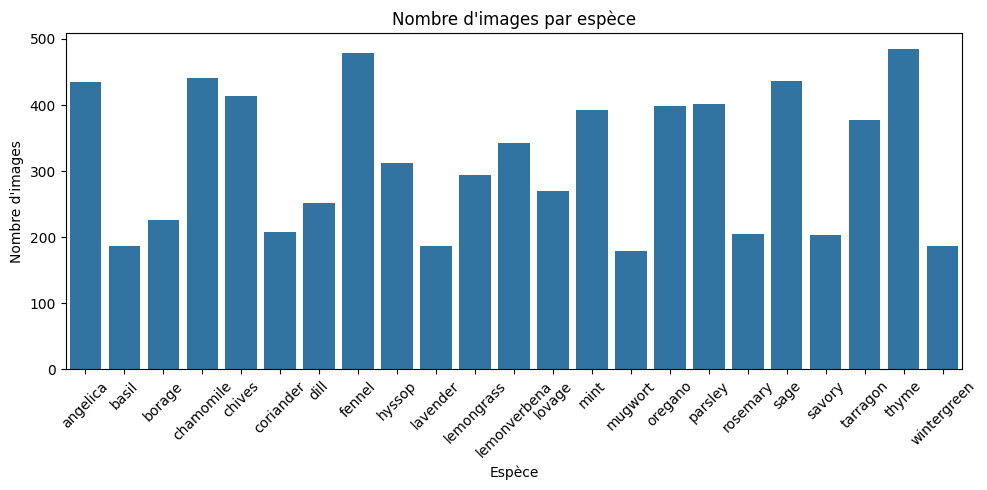

In [3]:
# Vérification de la distribution des classes

class_counts = df["label"].value_counts().sort_index()
display(class_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Nombre d'images par espèce")
plt.xlabel("Espèce")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
# Définir les modèles candidats du benchmark TensorFlow

TF_MODELS = {
    "MobileNetV2": {
        "builder": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        "input_size": (224, 224),
        "batch_size": 32,
    },
    "EfficientNetB0": {
        "builder": tf.keras.applications.EfficientNetB0,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "input_size": (224, 224),
        "batch_size": 32,
    },
    "ResNet50": {
        "builder": tf.keras.applications.ResNet50,
        "preprocess": tf.keras.applications.resnet50.preprocess_input,
        "input_size": (224, 224),
        "batch_size": 32,
    },
}

NUM_CLASSES = df["label"].nunique()
CLASS_NAMES = sorted(df["label"].unique())

print("Classes :", CLASS_NAMES)
print("Nombre de classes :", NUM_CLASSES)
print("Modèles testés :", list(TF_MODELS.keys()))


Classes : ['angelica', 'basil', 'borage', 'chamomile', 'chives', 'coriander', 'dill', 'fennel', 'hyssop', 'lavender', 'lemongrass', 'lemonverbena', 'lovage', 'mint', 'mugwort', 'oregano', 'parsley', 'rosemary', 'sage', 'savory', 'tarragon', 'thyme', 'wintergreen']
Nombre de classes : 23
Modèles testés : ['MobileNetV2', 'EfficientNetB0', 'ResNet50']


In [5]:
# Conclusion de l'étape 1

print("Etape 1 OK")
print(f"- Layout sélectionné : {DATA_LAYOUT}")
print(f"- Source            : {DATA_SOURCE_PATH}")
print(f"- Dataset détecté   : {len(df)} images")
print(f"- Classes           : {NUM_CLASSES}")
print(f"- Modèles TF        : {list(TF_MODELS.keys())}")


Etape 1 OK
- Layout sélectionné : all_images
- Source            : /home/thomashebert99/code/thomashebert99/plant_detect/data/all_images
- Dataset détecté   : 7314 images
- Classes           : 23
- Modèles TF        : ['MobileNetV2', 'EfficientNetB0', 'ResNet50']


In [6]:
# Split train / validation / test stratifié

from sklearn.model_selection import train_test_split

TEST_SIZE = 0.15
VAL_SIZE = 0.15
RANDOM_STATE = SEED

df_train_val, df_test = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

val_relative_size = VAL_SIZE / (1 - TEST_SIZE)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=val_relative_size,
    stratify=df_train_val["label"],
    random_state=RANDOM_STATE,
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Train size :", len(df_train))
print("Val size   :", len(df_val))
print("Test size  :", len(df_test))


Train size : 5119
Val size   : 1097
Test size  : 1098


,train,val,test
label,,,
angelica,0.059582,0.059253,0.059199
basil,0.025591,0.025524,0.025501
borage,0.030865,0.030994,0.030965
chamomile,0.060363,0.060164,0.060109
chives,0.056652,0.056518,0.056466
coriander,0.028521,0.028259,0.028233
dill,0.034382,0.034640,0.034608
fennel,0.065442,0.065634,0.065574
hyssop,0.042586,0.042844,0.042805


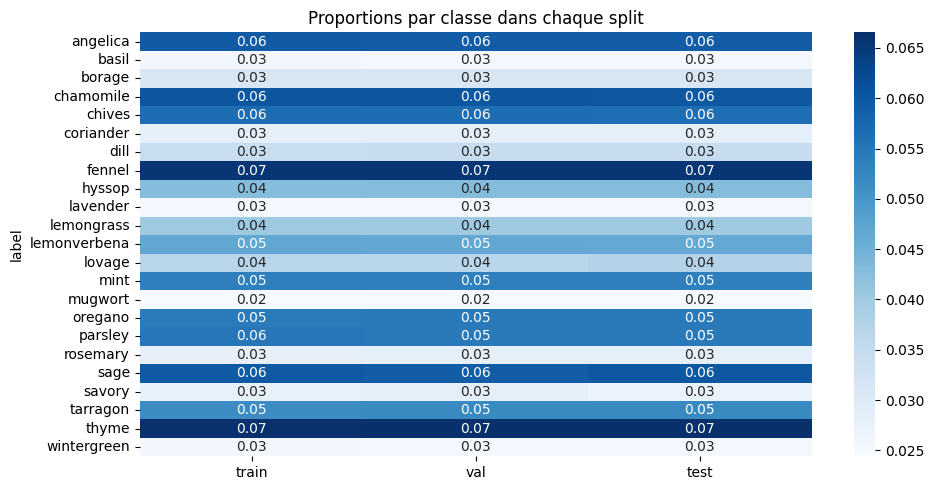

In [7]:
# Vérifier que la stratification est correcte

split_summary = pd.DataFrame({
    "train": df_train["label"].value_counts(normalize=True),
    "val": df_val["label"].value_counts(normalize=True),
    "test": df_test["label"].value_counts(normalize=True),
}).fillna(0)

display(split_summary)

plt.figure(figsize=(10, 5))
sns.heatmap(split_summary, annot=True, cmap="Blues", fmt=".2f")
plt.title("Proportions par classe dans chaque split")
plt.tight_layout()
plt.show()


In [8]:
# Encodage des labels

label_to_index = {label: idx for idx, label in enumerate(CLASS_NAMES)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

df_train["label_id"] = df_train["label"].map(label_to_index)
df_val["label_id"] = df_val["label"].map(label_to_index)
df_test["label_id"] = df_test["label"].map(label_to_index)

display(df_train.head())
print(label_to_index)


,filepath,filename,label,data_layout,label_source,label_id
0,/home/thomashebert99/code/thomashebert99/plant...,mint_0384.jpg,mint,all_images,files_df.csv,13
1,/home/thomashebert99/code/thomashebert99/plant...,hyssop_212.jpg,hyssop,all_images,files_df.csv,8
2,/home/thomashebert99/code/thomashebert99/plant...,lemongrass_127.jpg,lemongrass,all_images,files_df.csv,10
3,/home/thomashebert99/code/thomashebert99/plant...,tarragon_0363.jpg,tarragon,all_images,files_df.csv,20
4,/home/thomashebert99/code/thomashebert99/plant...,thyme_0395.jpg,thyme,all_images,files_df.csv,21


{'angelica': 0, 'basil': 1, 'borage': 2, 'chamomile': 3, 'chives': 4, 'coriander': 5, 'dill': 6, 'fennel': 7, 'hyssop': 8, 'lavender': 9, 'lemongrass': 10, 'lemonverbena': 11, 'lovage': 12, 'mint': 13, 'mugwort': 14, 'oregano': 15, 'parsley': 16, 'rosemary': 17, 'sage': 18, 'savory': 19, 'tarragon': 20, 'thyme': 21, 'wintergreen': 22}


In [9]:
# Fonction de lecture / preprocessing d'une image

def load_and_resize_image(filepath, label, image_size=(224, 224), preprocess_fn=None):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32)

    if preprocess_fn is not None:
        image = preprocess_fn(image)

    return image, label


In [10]:
# Fonction générique pour construire un tf.data.Dataset

def make_tf_dataset(
    dataframe,
    image_size=(224, 224),
    batch_size=32,
    preprocess_fn=None,
    shuffle=False,
):
    filepaths = dataframe["filepath"].astype(str).to_list()
    labels = dataframe["label_id"].astype("int32").to_list()

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    ds = ds.map(
        lambda x, y: load_and_resize_image(
            x,
            y,
            image_size=image_size,
            preprocess_fn=preprocess_fn,
        ),
        num_parallel_calls=AUTOTUNE,
    )

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


In [11]:
# Exemple: créer les datasets pour un modèle donné

MODEL_NAME = "EfficientNetB0"

model_config = TF_MODELS[MODEL_NAME]
image_size = model_config["input_size"]
preprocess_fn = model_config["preprocess"]

train_ds = make_tf_dataset(
    df_train,
    image_size=image_size,
    batch_size=TF_MODELS[MODEL_NAME].get("batch_size", BATCH_SIZE),
    preprocess_fn=preprocess_fn,
    shuffle=True,
)

val_ds = make_tf_dataset(
    df_val,
    image_size=image_size,
    batch_size=TF_MODELS[MODEL_NAME].get("batch_size", BATCH_SIZE),
    preprocess_fn=preprocess_fn,
    shuffle=False,
)

test_ds = make_tf_dataset(
    df_test,
    image_size=image_size,
    batch_size=TF_MODELS[MODEL_NAME].get("batch_size", BATCH_SIZE),
    preprocess_fn=preprocess_fn,
    shuffle=False,
)

print(train_ds)
print(val_ds)
print(test_ds)


I0000 00:00:1774206597.678249   54507 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21452 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


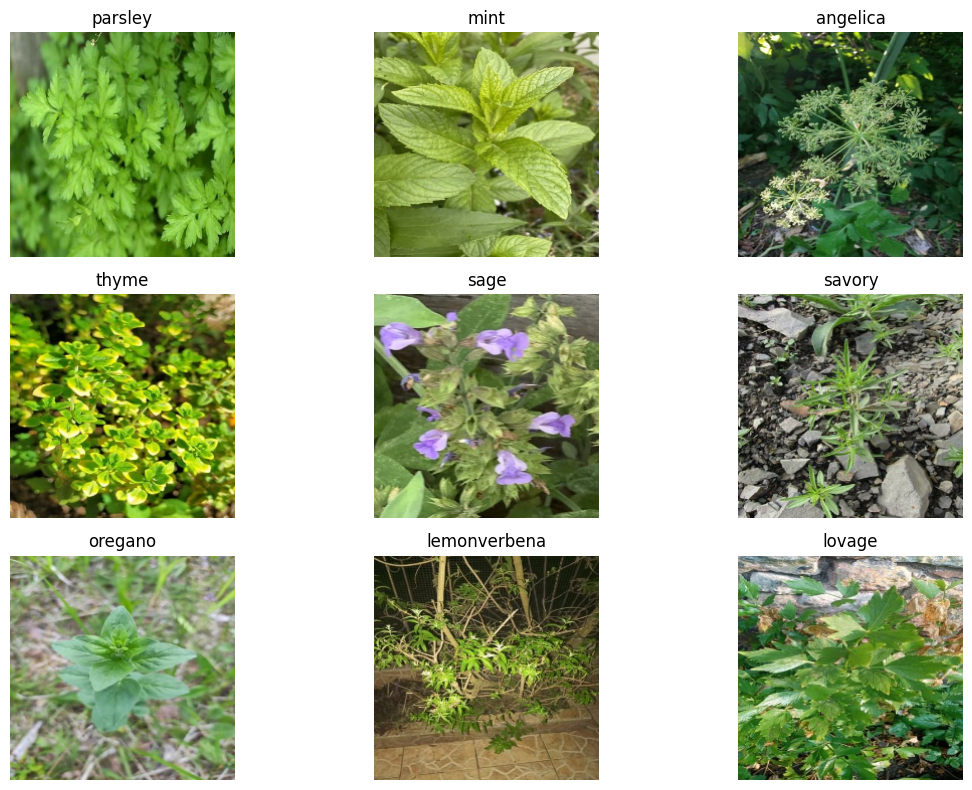

In [12]:
# Vérification visuelle rapide d'un batch

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)

    img = images[i].numpy()

    # Affichage plus lisible si preprocess_input a changé l'échelle
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img_to_show = (img - img_min) / (img_max - img_min)
    else:
        img_to_show = img

    plt.imshow(img_to_show)
    plt.title(index_to_label[int(labels[i].numpy())])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [13]:
# Hyperparamètres d'entraînement

from sklearn.utils.class_weight import compute_class_weight

EPOCHS_HEAD = 12
LEARNING_RATE_HEAD = 1e-3
DROPOUT_RATE = 0.30

# Recommandation pratique :
# - all_images : True, car le dataset est souvent plus déséquilibré
# - class_directories : False, car le dataset est en général beaucoup plus équilibré
USE_CLASS_WEIGHTS = DATA_LAYOUT == "all_images"

MODEL_SAVE_DIR = PROJECT_DIR / "notebooks" / "models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

def build_class_weights(dataframe):
    classes = np.array(sorted(dataframe["label_id"].unique()))
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=dataframe["label_id"].values,
    )
    return {int(cls): float(weight) for cls, weight in zip(classes, weights)}

CLASS_WEIGHTS = build_class_weights(df_train) if USE_CLASS_WEIGHTS else None

print("USE_CLASS_WEIGHTS :", USE_CLASS_WEIGHTS)
if CLASS_WEIGHTS is not None:
    display(pd.Series(CLASS_WEIGHTS, name="class_weight").sort_index())


USE_CLASS_WEIGHTS : True


0     0.729722
1     1.698971
2     1.408641
3     0.720276
4     0.767466
5     1.524419
6     1.264575
7     0.664374
8     1.020941
9     1.712040
10    1.080414
11    0.927355
12    1.177594
13    0.809328
14    1.780522
15    0.797725
16    0.789238
17    1.556400
18    0.727337
19    1.567361
20    0.843050
21    0.656535
22    1.698971
Name: class_weight, dtype: float64

In [14]:
# Data augmentation TensorFlow

def make_data_augmentation():
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.08),
            tf.keras.layers.RandomZoom(0.10),
            tf.keras.layers.RandomContrast(0.10),
        ],
        name="data_augmentation",
    )


In [15]:
# Fonction de construction du modèle

def build_transfer_model(
    model_name,
    num_classes,
    input_shape=(224, 224, 3),
    dropout_rate=0.30,
    train_base=False,
):
    config = TF_MODELS[model_name]
    base_builder = config["builder"]

    base_model = base_builder(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
    )
    base_model.trainable = train_base

    data_augmentation = make_data_augmentation()

    inputs = tf.keras.Input(shape=input_shape, name="input_image")
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="dropout")(x)
    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name="classifier",
    )(x)

    model = tf.keras.Model(inputs, outputs, name=f"{model_name}_transfer")
    return model, base_model


In [16]:
# Fonction de compilation

def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        ],
    )
    return model


In [17]:
# Callbacks d'entraînement

def make_callbacks(model_name):
    checkpoint_path = MODEL_SAVE_DIR / f"{model_name}_head_only_best.keras"

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    return callbacks, checkpoint_path


In [18]:
# Fonction d'entraînement générique pour un backbone

def train_head_only_model(
    model_name,
    df_train,
    df_val,
    num_classes,
    batch_size=32,
    epochs=12,
    learning_rate=1e-3,
    dropout_rate=0.30,
    use_class_weights=USE_CLASS_WEIGHTS,
):
    config = TF_MODELS[model_name]
    image_size = config["input_size"]
    preprocess_fn = config["preprocess"]

    train_ds = make_tf_dataset(
        df_train,
        image_size=image_size,
        batch_size=batch_size,
        preprocess_fn=preprocess_fn,
        shuffle=True,
    )

    val_ds = make_tf_dataset(
        df_val,
        image_size=image_size,
        batch_size=batch_size,
        preprocess_fn=preprocess_fn,
        shuffle=False,
    )

    model, base_model = build_transfer_model(
        model_name=model_name,
        num_classes=num_classes,
        input_shape=(*image_size, 3),
        dropout_rate=dropout_rate,
        train_base=False,
    )

    model = compile_model(model, learning_rate=learning_rate)
    callbacks, checkpoint_path = make_callbacks(model_name)
    class_weights = build_class_weights(df_train) if use_class_weights else None

    print(f"Class weights actifs pour {model_name} : {use_class_weights}")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
        class_weight=class_weights,
    )

    return {
        "model_name": model_name,
        "model": model,
        "base_model": base_model,
        "history": history,
        "train_ds": train_ds,
        "val_ds": val_ds,
        "checkpoint_path": checkpoint_path,
        "class_weights": class_weights,
        "use_class_weights": use_class_weights,
    }


In [19]:
# Lancer un premier entraînement sur un seul modèle

MODEL_NAME = "EfficientNetB0"

run = train_head_only_model(
    model_name=MODEL_NAME,
    df_train=df_train,
    df_val=df_val,
    num_classes=NUM_CLASSES,
    batch_size=TF_MODELS[MODEL_NAME].get("batch_size", BATCH_SIZE),
    epochs=EPOCHS_HEAD,
    learning_rate=LEARNING_RATE_HEAD,
    dropout_rate=DROPOUT_RATE,
)


Class weights actifs pour EfficientNetB0 : True
Epoch 1/12


I0000 00:00:1774206607.817374   54738 cuda_dnn.cc:461] Loaded cuDNN version 91002


160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2634 - loss: 2.6036
Epoch 1: val_accuracy improved from None to 0.57429, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3774 - loss: 2.2518 - val_accuracy: 0.5743 - val_loss: 1.5335 - learning_rate: 0.0010
Epoch 2/12
158/160 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5289 - loss: 1.6852
Epoch 2: val_accuracy improved from 0.57429 to 0.62717, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0

In [20]:
# Résumé du modèle

run["model"].summary()


Model: "EfficientNetB0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,137,962 (15.79 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 58,928 (230.19 KB)

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.377417,2.251811,0.574294,1.533458,0.001
1,0.549912,1.593045,0.627165,1.254542,0.001
2,0.595233,1.401442,0.666363,1.112731,0.001
3,0.632545,1.264382,0.667274,1.063239,0.001
4,0.647001,1.186964,0.685506,1.014189,0.001


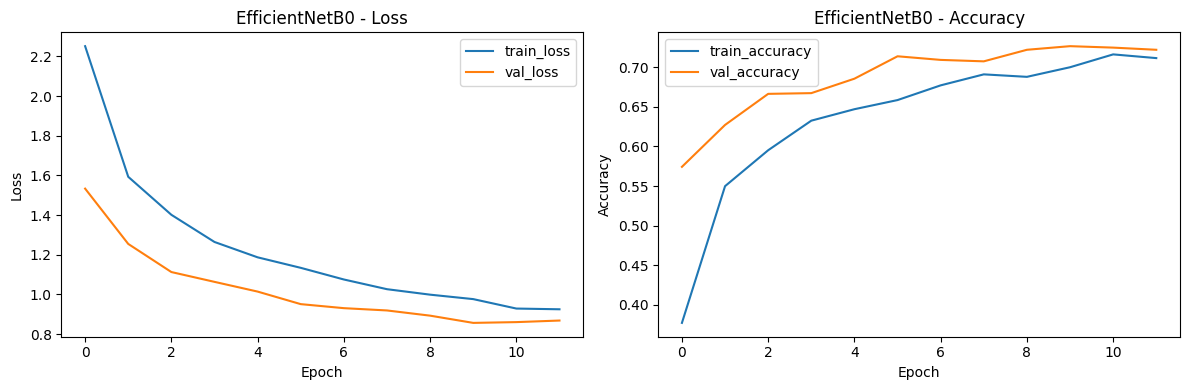

In [21]:
# Visualiser les courbes d'entraînement

history_df = pd.DataFrame(run["history"].history)
display(history_df.head())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title(f"{run['model_name']} - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title(f"{run['model_name']} - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [22]:
# Entraîner plusieurs backbones avec la même fonction

training_runs = {}

for model_name in TF_MODELS.keys():
    print(f"\n===== Training {model_name} =====")
    training_runs[model_name] = train_head_only_model(
        model_name=model_name,
        df_train=df_train,
        df_val=df_val,
        num_classes=NUM_CLASSES,
        batch_size=TF_MODELS[model_name].get("batch_size", BATCH_SIZE),
        epochs=EPOCHS_HEAD,
        learning_rate=LEARNING_RATE_HEAD,
        dropout_rate=DROPOUT_RATE,
    )



===== Training MobileNetV2 =====
Class weights actifs pour MobileNetV2 : True
Epoch 1/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1885 - loss: 2.9874
Epoch 1: val_accuracy improved from None to 0.33637, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/MobileNetV2_head_only_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/MobileNetV2_head_only_best.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.2835 - loss: 2.5657 - val_accuracy: 0.3364 - val_loss: 2.1626 - learning_rate: 0.0010
Epoch 2/12
159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4212 - loss: 1.9789
Epoch 2: val_accuracy improved from 0.33637 to 0.45761, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/MobileNetV2_head_only_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/MobileNetV2

In [23]:
# Tableau de synthèse validation

head_results = []

for model_name, run in training_runs.items():
    hist = pd.DataFrame(run["history"].history)
    best_idx = hist["val_accuracy"].idxmax()

    head_results.append({
        "model_name": model_name,
        "best_val_accuracy": hist.loc[best_idx, "val_accuracy"],
        "val_loss_at_best": hist.loc[best_idx, "val_loss"],
        "train_accuracy_at_best": hist.loc[best_idx, "accuracy"],
        "epochs_ran": len(hist),
    })

head_results_df = pd.DataFrame(head_results).sort_values(
    by="best_val_accuracy",
    ascending=False,
).reset_index(drop=True)

display(head_results_df)


,model_name,best_val_accuracy,val_loss_at_best,train_accuracy_at_best,epochs_ran
0,EfficientNetB0,0.730173,0.862002,0.696034,12
1,ResNet50,0.577028,1.443387,0.684118,12
2,MobileNetV2,0.501367,1.601202,0.538972,9


In [24]:
# Etendre la liste des modèles candidats

TF_MODELS = {
    "MobileNetV2": {
        "builder": tf.keras.applications.MobileNetV2,
        "preprocess": tf.keras.applications.mobilenet_v2.preprocess_input,
        "input_size": (224, 224),
        "batch_size": 32,
    },
    "EfficientNetB0": {
        "builder": tf.keras.applications.EfficientNetB0,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "input_size": (224, 224),
        "batch_size": 32,
    },
    "EfficientNetB3": {
        "builder": tf.keras.applications.EfficientNetB3,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "input_size": (300, 300),
        "batch_size": 16,
    },
    "EfficientNetB4": {
        "builder": tf.keras.applications.EfficientNetB4,
        "preprocess": tf.keras.applications.efficientnet.preprocess_input,
        "input_size": (380, 380),
        "batch_size": 8,
    },
    "ResNet50": {
        "builder": tf.keras.applications.ResNet50,
        "preprocess": tf.keras.applications.resnet50.preprocess_input,
        "input_size": (224, 224),
        "batch_size": 32,
    },
    "EfficientNetV2B0": {
        "builder": tf.keras.applications.EfficientNetV2B0,
        "preprocess": tf.keras.applications.efficientnet_v2.preprocess_input,
        "input_size": (224, 224),
        "batch_size": 32,
    },
    "EfficientNetV2B1": {
        "builder": tf.keras.applications.EfficientNetV2B1,
        "preprocess": tf.keras.applications.efficientnet_v2.preprocess_input,
        "input_size": (240, 240),
        "batch_size": 24,
    },
    "EfficientNetV2S": {
        "builder": tf.keras.applications.EfficientNetV2S,
        "preprocess": tf.keras.applications.efficientnet_v2.preprocess_input,
        "input_size": (384, 384),
        "batch_size": 8,
    },
    "DenseNet121": {
        "builder": tf.keras.applications.DenseNet121,
        "preprocess": tf.keras.applications.densenet.preprocess_input,
        "input_size": (224, 224),
        "batch_size": 32,
    },
    "MobileNetV3Large": {
        "builder": tf.keras.applications.MobileNetV3Large,
        "preprocess": tf.keras.applications.mobilenet_v3.preprocess_input,
        "input_size": (224, 224),
        "batch_size": 32,
    },
    "ConvNeXtTiny": {
        "builder": tf.keras.applications.ConvNeXtTiny,
        "preprocess": lambda x: x,
        "input_size": (224, 224),
        "batch_size": 16,
    },
}

print(list(TF_MODELS.keys()))


['MobileNetV2', 'EfficientNetB0', 'EfficientNetB3', 'EfficientNetB4', 'ResNet50', 'EfficientNetV2B0', 'EfficientNetV2B1', 'EfficientNetV2S', 'DenseNet121', 'MobileNetV3Large', 'ConvNeXtTiny']


In [25]:
# Sélection des candidats à benchmarker

CANDIDATE_MODELS = [
    "EfficientNetB0",
    "EfficientNetB3",
    "EfficientNetB4",
    "EfficientNetV2B0",
    "EfficientNetV2B1",
    "EfficientNetV2S",
    "DenseNet121",
    "MobileNetV3Large",
    "ConvNeXtTiny",
]

print(CANDIDATE_MODELS)


['EfficientNetB0', 'EfficientNetB3', 'EfficientNetB4', 'EfficientNetV2B0', 'EfficientNetV2B1', 'EfficientNetV2S', 'DenseNet121', 'MobileNetV3Large', 'ConvNeXtTiny']


In [26]:
# Petit utilitaire pour compter les paramètres

def count_params_millions(model):
    return model.count_params() / 1_000_000


In [27]:
# Benchmark propre de plusieurs candidats

import gc
import time

BENCHMARK_EPOCHS = 20
BENCHMARK_BATCH_SIZE = 32
BENCHMARK_LR = 1e-3
BENCHMARK_DROPOUT = 0.30

benchmark_runs = {}
benchmark_rows = []

for model_name in CANDIDATE_MODELS:
    print(f"\n{'=' * 15} {model_name} {'=' * 15}")

    tf.keras.backend.clear_session()
    gc.collect()

    model_batch_size = TF_MODELS[model_name].get("batch_size", BENCHMARK_BATCH_SIZE)
    print(f"input_size={TF_MODELS[model_name]['input_size']}, batch_size={model_batch_size}")

    start_time = time.time()

    run = train_head_only_model(
        model_name=model_name,
        df_train=df_train,
        df_val=df_val,
        num_classes=NUM_CLASSES,
        batch_size=model_batch_size,
        epochs=BENCHMARK_EPOCHS,
        learning_rate=BENCHMARK_LR,
        dropout_rate=BENCHMARK_DROPOUT,
    )

    elapsed = time.time() - start_time
    hist = pd.DataFrame(run["history"].history)
    best_idx = hist["val_accuracy"].idxmax()

    benchmark_runs[model_name] = run
    benchmark_rows.append({
        "model_name": model_name,
        "best_val_accuracy": hist.loc[best_idx, "val_accuracy"],
        "val_loss_at_best": hist.loc[best_idx, "val_loss"],
        "train_accuracy_at_best": hist.loc[best_idx, "accuracy"],
        "epochs_ran": len(hist),
        "best_epoch": int(best_idx) + 1,
        "train_time_min": elapsed / 60,
        "input_size": TF_MODELS[model_name]["input_size"],
        "batch_size": model_batch_size,
        "params_millions": count_params_millions(run["model"]),
    })

benchmark_results_df = pd.DataFrame(benchmark_rows).sort_values(
    by="best_val_accuracy",
    ascending=False,
).reset_index(drop=True)

display(benchmark_results_df)



=============== EfficientNetB0 ===============
input_size=(224, 224), batch_size=32
Class weights actifs pour EfficientNetB0 : True
Epoch 1/20
158/160 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2539 - loss: 2.6657
Epoch 1: val_accuracy improved from None to 0.55697, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.3690 - loss: 2.2782 - val_accuracy: 0.5570 - val_loss: 1.5542 - learning_rate: 0.0010
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5271 - loss: 1.6909
Epoch 2: val_accuracy improved from 0.55697 to 0.62717, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB0_head_only_best.keras

Epoch 2: finished saving model to /home/thomashebert

I0000 00:00:1774208611.656137   54723 service.cc:153] XLA service 0x73de74204580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774208611.656233   54723 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1774208611.938880   54723 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
E0000 00:00:1774208613.785588   54723 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


318/320 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2932 - loss: 2.5000

E0000 00:00:1774208624.900828   54731 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2941 - loss: 2.4971

E0000 00:00:1774208630.377589   54733 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.60346, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/ConvNeXtTiny_head_only_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/ConvNeXtTiny_head_only_best.keras
320/320 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.4243 - loss: 2.0403 - val_accuracy: 0.6035 - val_loss: 1.3697 - learning_rate: 0.0010
Epoch 2/20
319/320 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5944 - loss: 1.4228
Epoch 2: val_accuracy improved from 0.60346 to 0.66363, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/ConvNeXtTiny_head_only_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/ConvNeXtTiny_head_only_best.keras
320/320 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.6120 - loss: 1.3488 - val_accuracy: 0.6636 - val_loss: 1.1399 - learning_rate: 0.

,model_name,best_val_accuracy,val_loss_at_best,train_accuracy_at_best,epochs_ran,best_epoch,train_time_min,input_size,batch_size,params_millions
0,EfficientNetV2S,0.824066,0.570912,0.811877,18,14,8.279405,"(384, 384)",8,20.360823
1,EfficientNetB4,0.798541,0.658159,0.810315,18,14,9.111928,"(380, 380)",8,17.715062
2,EfficientNetB3,0.783045,0.675653,0.799375,18,14,4.385062,"(300, 300)",16,10.818886
3,ConvNeXtTiny,0.743847,0.826519,0.780817,20,19,3.778125,"(224, 224)",16,27.837815
4,EfficientNetB0,0.737466,0.856341,0.705802,14,10,1.261158,"(224, 224)",32,4.079034
5,EfficientNetV2B1,0.737466,0.870397,0.719672,17,13,2.119789,"(240, 240)",24,6.960587
6,MobileNetV3Large,0.721969,0.914314,0.672788,14,10,0.878085,"(224, 224)",32,3.018455
7,EfficientNetV2B0,0.716500,0.913828,0.701114,14,10,1.191962,"(224, 224)",32,5.948775
8,DenseNet121,0.618049,1.257974,0.569838,14,10,1.857465,"(224, 224)",32,7.061079


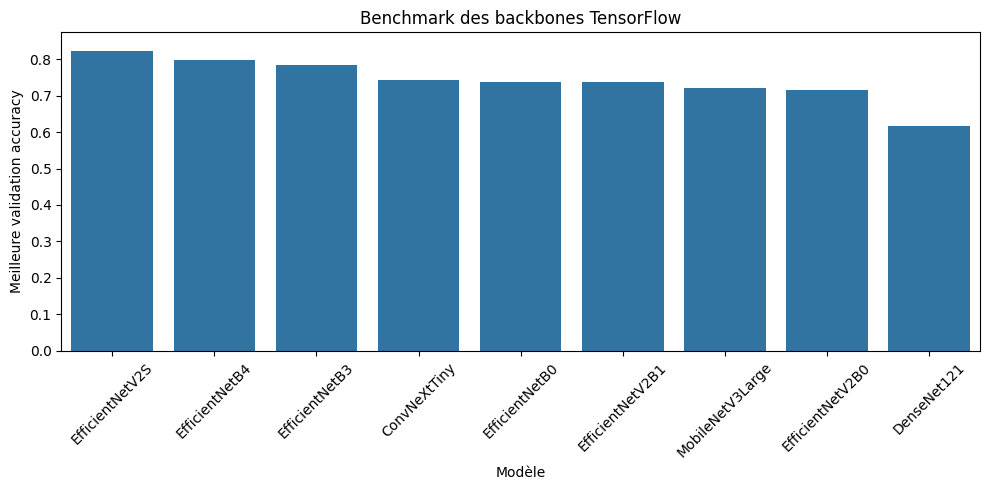

In [28]:
# Visualiser le classement des candidats

plt.figure(figsize=(10, 5))
sns.barplot(
    data=benchmark_results_df,
    x="model_name",
    y="best_val_accuracy",
)
plt.title("Benchmark des backbones TensorFlow")
plt.xlabel("Modèle")
plt.ylabel("Meilleure validation accuracy")
plt.xticks(rotation=45)
plt.ylim(0, min(1.0, benchmark_results_df["best_val_accuracy"].max() + 0.05))
plt.tight_layout()
plt.show()


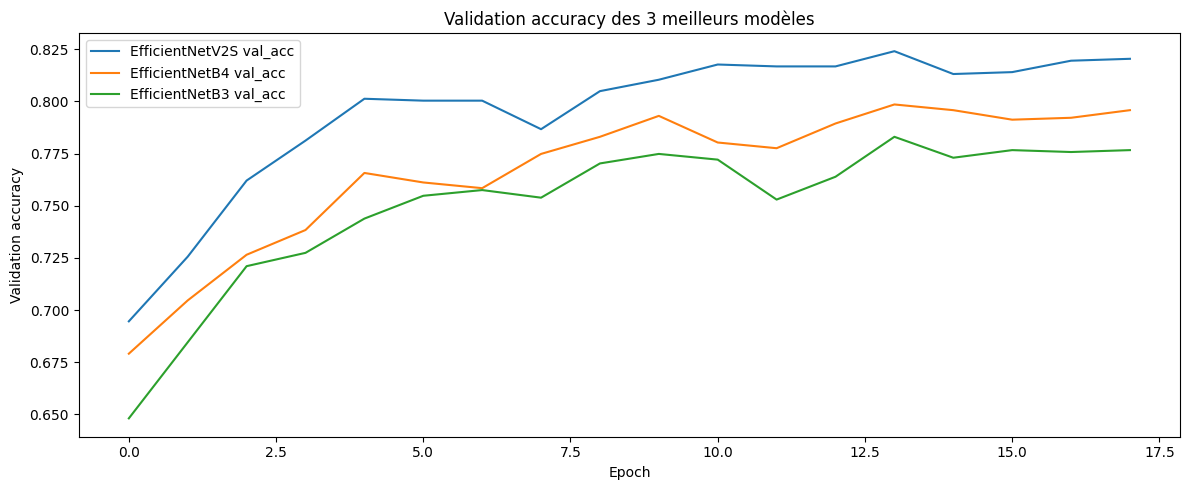

In [29]:
# Comparer les courbes des meilleurs candidats

top_k = 3
top_models = benchmark_results_df.head(top_k)["model_name"].tolist()

plt.figure(figsize=(12, 5))

for model_name in top_models:
    hist = pd.DataFrame(benchmark_runs[model_name]["history"].history)
    plt.plot(hist["val_accuracy"], label=f"{model_name} val_acc")

plt.title(f"Validation accuracy des {top_k} meilleurs modèles")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Extraire les meilleurs candidats pour la suite

TOP_MODELS_FOR_FINETUNING = benchmark_results_df.head(2)["model_name"].tolist()

print("Modèles retenus pour le fine-tuning :", TOP_MODELS_FOR_FINETUNING)
benchmark_results_df

Modèles retenus pour le fine-tuning : ['EfficientNetV2S', 'EfficientNetB4']


,model_name,best_val_accuracy,val_loss_at_best,train_accuracy_at_best,epochs_ran,best_epoch,train_time_min,input_size,batch_size,params_millions
0,EfficientNetV2S,0.824066,0.570912,0.811877,18,14,8.279405,"(384, 384)",8,20.360823
1,EfficientNetB4,0.798541,0.658159,0.810315,18,14,9.111928,"(380, 380)",8,17.715062
2,EfficientNetB3,0.783045,0.675653,0.799375,18,14,4.385062,"(300, 300)",16,10.818886
3,ConvNeXtTiny,0.743847,0.826519,0.780817,20,19,3.778125,"(224, 224)",16,27.837815
4,EfficientNetB0,0.737466,0.856341,0.705802,14,10,1.261158,"(224, 224)",32,4.079034
5,EfficientNetV2B1,0.737466,0.870397,0.719672,17,13,2.119789,"(240, 240)",24,6.960587
6,MobileNetV3Large,0.721969,0.914314,0.672788,14,10,0.878085,"(224, 224)",32,3.018455
7,EfficientNetV2B0,0.716500,0.913828,0.701114,14,10,1.191962,"(224, 224)",32,5.948775
8,DenseNet121,0.618049,1.257974,0.569838,14,10,1.857465,"(224, 224)",32,7.061079


In [31]:
# Evaluation multiclasses robuste des modèles benchmarkés

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    top_k_accuracy_score,
)

EVAL_SPLIT_NAME = "val"  # "val" pour sélectionner les modèles, "test" pour l'évaluation finale
EVAL_DF = df_val if EVAL_SPLIT_NAME == "val" else df_test
TOP_K = min(3, NUM_CLASSES)


def get_eval_dataset(dataframe, model_name):
    model_config = TF_MODELS[model_name]
    return make_tf_dataset(
        dataframe,
        image_size=model_config["input_size"],
        batch_size=model_config.get("batch_size", BATCH_SIZE),
        preprocess_fn=model_config["preprocess"],
        shuffle=False,
    )


def predict_multiclass(model, dataframe, model_name):
    eval_ds = get_eval_dataset(dataframe, model_name)
    y_true = dataframe["label_id"].astype(int).to_numpy()
    y_proba = model.predict(eval_ds, verbose=0)
    y_pred = y_proba.argmax(axis=1)
    return y_true, y_pred, y_proba


def evaluate_multiclass_model(run, dataframe, split_name="val"):
    model_name = run["model_name"]
    y_true, y_pred, y_proba = predict_multiclass(run["model"], dataframe, model_name)

    metrics = {
        "model_name": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "top_3_accuracy": top_k_accuracy_score(y_true, y_proba, k=TOP_K, labels=np.arange(NUM_CLASSES)),
        "log_loss": log_loss(y_true, y_proba, labels=np.arange(NUM_CLASSES)),
        "input_size": TF_MODELS[model_name]["input_size"],
        "batch_size": TF_MODELS[model_name].get("batch_size", BATCH_SIZE),
        "params_millions": count_params_millions(run["model"]),
    }

    # Score composite pour classer les modèles malgré l'imbalance.
    metrics["ranking_score"] = (
        0.45 * metrics["macro_f1"]
        + 0.30 * metrics["balanced_accuracy"]
        + 0.15 * metrics["top_3_accuracy"]
        + 0.10 * metrics["accuracy"]
    )

    return {
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


def evaluate_model_runs(model_runs, dataframe, split_name="val"):
    evaluation_rows = []
    evaluation_artifacts = {}

    for model_name, run in model_runs.items():
        evaluation = evaluate_multiclass_model(run, dataframe, split_name=split_name)
        evaluation_artifacts[model_name] = evaluation
        evaluation_rows.append(evaluation["metrics"])

    evaluation_df = pd.DataFrame(evaluation_rows).sort_values(
        by=["ranking_score", "macro_f1", "balanced_accuracy", "accuracy", "top_3_accuracy", "log_loss"],
        ascending=[False, False, False, False, False, True],
    ).reset_index(drop=True)

    return evaluation_df, evaluation_artifacts


In [32]:
# Evaluer et classer les modèles benchmarkés avec plusieurs métriques

model_eval_df, model_eval_artifacts = evaluate_model_runs(
    benchmark_runs,
    EVAL_DF,
    split_name=EVAL_SPLIT_NAME,
)

display(model_eval_df)


,model_name,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,input_size,batch_size,params_millions,ranking_score
0,EfficientNetV2S,val,0.824066,0.818625,0.806992,0.818625,0.810347,0.825572,0.955333,0.570912,"(384, 384)",8,20.360823,0.835950
1,EfficientNetB4,val,0.798541,0.786999,0.783913,0.786999,0.780677,0.799424,0.935278,0.658159,"(380, 380)",8,17.715062,0.807550
2,EfficientNetB3,val,0.783045,0.776734,0.776074,0.776734,0.770378,0.783218,0.938013,0.675653,"(300, 300)",16,10.818886,0.798697
3,ConvNeXtTiny,val,0.743847,0.740306,0.734293,0.740306,0.728075,0.746435,0.918870,0.826519,"(224, 224)",16,27.837815,0.761941
4,EfficientNetV2B1,val,0.737466,0.732142,0.733541,0.732142,0.722149,0.738010,0.904284,0.870397,"(240, 240)",24,6.960587,0.753999
5,EfficientNetB0,val,0.737466,0.731283,0.725320,0.731283,0.717787,0.736918,0.917958,0.856341,"(224, 224)",32,4.079034,0.753829
6,MobileNetV3Large,val,0.721969,0.714351,0.722937,0.714351,0.708431,0.720790,0.905196,0.914313,"(224, 224)",32,3.018455,0.741076
7,EfficientNetV2B0,val,0.716500,0.706304,0.701026,0.706304,0.693563,0.714579,0.896080,0.913828,"(224, 224)",32,5.948775,0.730056
8,DenseNet121,val,0.618049,0.611676,0.610266,0.611676,0.584470,0.607135,0.818596,1.257974,"(224, 224)",32,7.061079,0.631108


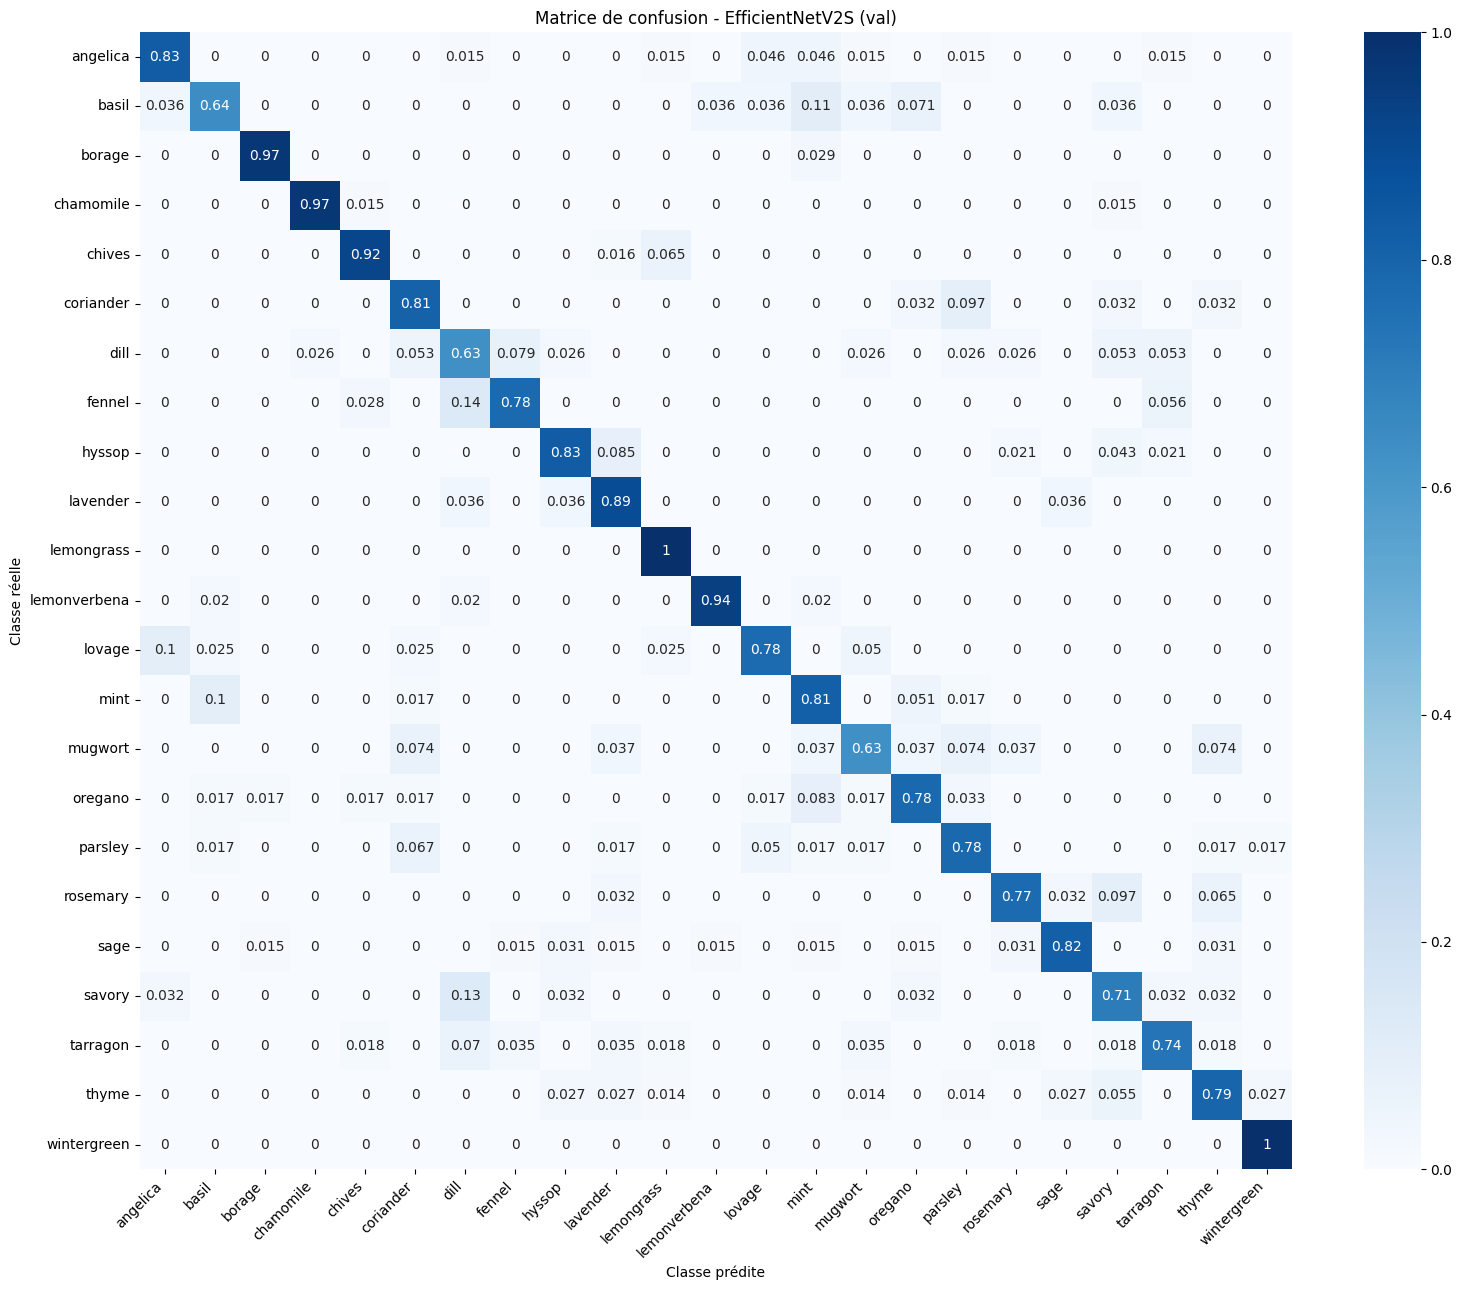

In [33]:
# Matrice de confusion du meilleur modèle selon le ranking multicritère

CONFUSION_MODEL_NAME = model_eval_df.loc[0, "model_name"]
CONFUSION_NORMALIZE = "true"  # "true", "pred", "all" ou None

best_eval = model_eval_artifacts[CONFUSION_MODEL_NAME]
cm = confusion_matrix(
    best_eval["y_true"],
    best_eval["y_pred"],
    labels=np.arange(NUM_CLASSES),
    normalize=CONFUSION_NORMALIZE,
)

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot=True,
)
plt.title(f"Matrice de confusion - {CONFUSION_MODEL_NAME} ({EVAL_SPLIT_NAME})")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [34]:
# Rapport détaillé par classe pour le meilleur modèle

BEST_MODEL_NAME = model_eval_df.loc[0, "model_name"]
best_eval = model_eval_artifacts[BEST_MODEL_NAME]

best_report_df = pd.DataFrame(
    classification_report(
        best_eval["y_true"],
        best_eval["y_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T

TOP_MODELS_FOR_FINETUNING = model_eval_df.head(2)["model_name"].tolist()

print("Meilleur modèle selon le ranking multicritère :", BEST_MODEL_NAME)
print("Modèles retenus pour le fine-tuning :", TOP_MODELS_FOR_FINETUNING)
display(best_report_df)


Meilleur modèle selon le ranking multicritère : EfficientNetV2S
Modèles retenus pour le fine-tuning : ['EfficientNetV2S', 'EfficientNetB4']


,precision,recall,f1-score,support
angelica,0.900000,0.830769,0.864000,65.000000
basil,0.642857,0.642857,0.642857,28.000000
borage,0.942857,0.970588,0.956522,34.000000
chamomile,0.984615,0.969697,0.977099,66.000000
chives,0.919355,0.919355,0.919355,62.000000
coriander,0.694444,0.806452,0.746269,31.000000
dill,0.533333,0.631579,0.578313,38.000000
fennel,0.903226,0.777778,0.835821,72.000000
hyssop,0.847826,0.829787,0.838710,47.000000
lavender,0.657895,0.892857,0.757576,28.000000


In [35]:
# Garder les 2 meilleurs modèles avant fine-tuning

FINE_TUNE_TOP_N_MODELS = 2
TOP_MODELS_FOR_FINETUNING = model_eval_df.head(FINE_TUNE_TOP_N_MODELS)["model_name"].tolist()

print("Modèles retenus pour le fine-tuning :", TOP_MODELS_FOR_FINETUNING)
display(model_eval_df.head(FINE_TUNE_TOP_N_MODELS))


Modèles retenus pour le fine-tuning : ['EfficientNetV2S', 'EfficientNetB4']


,model_name,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,input_size,batch_size,params_millions,ranking_score
0,EfficientNetV2S,val,0.824066,0.818625,0.806992,0.818625,0.810347,0.825572,0.955333,0.570912,"(384, 384)",8,20.360823,0.83595
1,EfficientNetB4,val,0.798541,0.786999,0.783913,0.786999,0.780677,0.799424,0.935278,0.658159,"(380, 380)",8,17.715062,0.80755


In [36]:
# Outils de métriques et callback de ranking sur la validation

from itertools import product
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    top_k_accuracy_score,
)

TOP_K = min(3, NUM_CLASSES)


def compute_ranking_metrics(y_true, y_pred, y_proba):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "top_3_accuracy": top_k_accuracy_score(
            y_true,
            y_proba,
            k=TOP_K,
            labels=np.arange(NUM_CLASSES),
        ),
        "log_loss": log_loss(y_true, y_proba, labels=np.arange(NUM_CLASSES)),
    }

    metrics["ranking_score"] = (
        0.45 * metrics["macro_f1"]
        + 0.30 * metrics["balanced_accuracy"]
        + 0.15 * metrics["top_3_accuracy"]
        + 0.10 * metrics["accuracy"]
    )
    return metrics


class ValidationRankingCallback(tf.keras.callbacks.Callback):
    def __init__(self, eval_ds, y_true):
        super().__init__()
        self.eval_ds = eval_ds
        self.y_true = y_true

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        y_proba = self.model.predict(self.eval_ds, verbose=0)
        y_pred = y_proba.argmax(axis=1)
        metrics = compute_ranking_metrics(self.y_true, y_pred, y_proba)

        logs["val_eval_accuracy"] = metrics["accuracy"]
        logs["val_balanced_accuracy"] = metrics["balanced_accuracy"]
        logs["val_macro_precision"] = metrics["macro_precision"]
        logs["val_macro_recall"] = metrics["macro_recall"]
        logs["val_macro_f1"] = metrics["macro_f1"]
        logs["val_weighted_f1"] = metrics["weighted_f1"]
        logs["val_top_3_accuracy"] = metrics["top_3_accuracy"]
        logs["val_eval_log_loss"] = metrics["log_loss"]
        logs["val_ranking_score"] = metrics["ranking_score"]

        print(
            f" - val_macro_f1: {metrics['macro_f1']:.4f}"
            f" - val_balanced_accuracy: {metrics['balanced_accuracy']:.4f}"
            f" - val_top_3_accuracy: {metrics['top_3_accuracy']:.4f}"
            f" - val_ranking_score: {metrics['ranking_score']:.4f}"
        )


In [37]:
# Outils de fine-tuning

def find_backbone_model(model):
    candidate_layers = [
        layer
        for layer in model.layers
        if isinstance(layer, tf.keras.Model) and layer.name not in {model.name, "data_augmentation"}
    ]

    if not candidate_layers:
        raise ValueError("Impossible de retrouver le backbone dans le modèle Keras.")

    return max(candidate_layers, key=lambda layer: len(layer.layers))


def set_fine_tune_layers(base_model, unfreeze_fraction=0.30, freeze_batchnorm=True):
    for layer in base_model.layers:
        layer.trainable = False

    n_layers = len(base_model.layers)
    n_unfreeze = max(1, int(n_layers * unfreeze_fraction))

    for layer in base_model.layers[-n_unfreeze:]:
        if freeze_batchnorm and isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
    return n_unfreeze, trainable_layers


def compile_fine_tune_model(model, learning_rate=1e-5):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model


def make_fine_tune_callbacks(model_name, trial_name):
    checkpoint_path = MODEL_SAVE_DIR / f"{model_name}_{trial_name}_finetune_best.keras"

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    return callbacks, checkpoint_path


In [38]:
# Espace de recherche d'hyperparamètres

RUN_EXHAUSTIVE_FINE_TUNE_SEARCH = False
MAX_TRIALS_PER_MODEL = 3
FINE_TUNE_MAX_EPOCHS = 20

FINE_TUNE_SEARCH_SPACE = {
    "unfreeze_fraction": [0.20, 0.40],
    "learning_rate": [1e-5, 3e-5],
    "fine_tune_epochs": [FINE_TUNE_MAX_EPOCHS],
    "use_class_weights": [USE_CLASS_WEIGHTS],
    "freeze_batchnorm": [True],
}


def build_search_configs(search_space, exhaustive=False, max_trials=8, seed=SEED):
    keys = list(search_space.keys())
    all_configs = [dict(zip(keys, values)) for values in product(*search_space.values())]

    rng = random.Random(seed)
    rng.shuffle(all_configs)

    if exhaustive or len(all_configs) <= max_trials:
        return all_configs

    return all_configs[:max_trials]


print("Recherche exhaustive :", RUN_EXHAUSTIVE_FINE_TUNE_SEARCH)
print("Nombre max de trials par modèle :", MAX_TRIALS_PER_MODEL)
print("Epochs max de fine-tuning :", FINE_TUNE_MAX_EPOCHS)
print("Top 4 modèles sélectionnés :", TOP_MODELS_FOR_FINETUNING)


Recherche exhaustive : False
Nombre max de trials par modèle : 3
Epochs max de fine-tuning : 20
Top 4 modèles sélectionnés : ['EfficientNetV2S', 'EfficientNetB4']


In [39]:
# Une fonction pour un trial de fine-tuning

def fine_tune_single_trial(
    model_name,
    base_checkpoint_path,
    config,
    df_train,
    df_val,
    num_classes,
    trial_name,
):
    model_config = TF_MODELS[model_name]
    batch_size = model_config.get("batch_size", BATCH_SIZE)

    train_ds = make_tf_dataset(
        df_train,
        image_size=model_config["input_size"],
        batch_size=batch_size,
        preprocess_fn=model_config["preprocess"],
        shuffle=True,
    )

    val_ds = make_tf_dataset(
        df_val,
        image_size=model_config["input_size"],
        batch_size=batch_size,
        preprocess_fn=model_config["preprocess"],
        shuffle=False,
    )

    y_val = df_val["label_id"].astype(int).to_numpy()

    model = tf.keras.models.load_model(base_checkpoint_path)
    base_model = find_backbone_model(model)

    n_unfreeze, trainable_layers = set_fine_tune_layers(
        base_model,
        unfreeze_fraction=config["unfreeze_fraction"],
        freeze_batchnorm=config["freeze_batchnorm"],
    )

    model = compile_fine_tune_model(
        model,
        learning_rate=config["learning_rate"],
    )

    class_weights = build_class_weights(df_train) if config["use_class_weights"] else None
    callbacks, checkpoint_path = make_fine_tune_callbacks(model_name, trial_name)

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=config["fine_tune_epochs"],
        callbacks=callbacks,
        verbose=1,
        class_weight=class_weights,
    )

    elapsed = time.time() - start_time

    best_model = tf.keras.models.load_model(checkpoint_path)
    eval_run = {
        "model_name": model_name,
        "model": best_model,
    }

    evaluation = evaluate_multiclass_model(eval_run, df_val, split_name="val")

    history_df = pd.DataFrame(history.history)
    best_epoch = (
        int(history_df["val_loss"].idxmin()) + 1
        if "val_loss" in history_df
        else len(history_df)
    )

    metrics = dict(evaluation["metrics"])
    metrics.update({
        "trial_name": trial_name,
        "fine_tune_learning_rate": config["learning_rate"],
        "fine_tune_epochs": config["fine_tune_epochs"],
        "unfreeze_fraction": config["unfreeze_fraction"],
        "freeze_batchnorm": config["freeze_batchnorm"],
        "use_class_weights": config["use_class_weights"],
        "requested_unfreeze_layers": n_unfreeze,
        "trainable_backbone_layers": trainable_layers,
        "best_epoch": best_epoch,
        "epochs_ran": len(history_df),
        "train_time_min": elapsed / 60,
        "checkpoint_path": str(checkpoint_path),
        "base_checkpoint_path": str(base_checkpoint_path),
    })

    return {
        "model_name": model_name,
        "trial_name": trial_name,
        "config": config,
        "metrics": metrics,
        "checkpoint_path": str(checkpoint_path),
    }


In [40]:
# Lancer la recherche de fine-tuning sur les 4 meilleurs modèles

import gc
import time

fine_tune_trial_rows = []
best_fine_tune_trials = {}

for model_rank, model_name in enumerate(TOP_MODELS_FOR_FINETUNING, start=1):
    print(f"\n{'=' * 20} Fine-tuning search: {model_name} {'=' * 20}")

    base_checkpoint_path = benchmark_runs[model_name]["checkpoint_path"]

    trial_configs = build_search_configs(
        FINE_TUNE_SEARCH_SPACE,
        exhaustive=RUN_EXHAUSTIVE_FINE_TUNE_SEARCH,
        max_trials=MAX_TRIALS_PER_MODEL,
        seed=SEED + model_rank,
    )

    print(f"Nombre de configurations testées pour {model_name} : {len(trial_configs)}")

    for trial_idx, config in enumerate(trial_configs, start=1):
        print(f"\n--- {model_name} | trial {trial_idx:02d}/{len(trial_configs)} ---")
        print(config)

        tf.keras.backend.clear_session()
        gc.collect()

        trial_name = f"trial_{trial_idx:02d}"

        trial_result = fine_tune_single_trial(
            model_name=model_name,
            base_checkpoint_path=base_checkpoint_path,
            config=config,
            df_train=df_train,
            df_val=df_val,
            num_classes=NUM_CLASSES,
            trial_name=trial_name,
        )

        fine_tune_trial_rows.append(trial_result["metrics"])

        current_best = best_fine_tune_trials.get(model_name)
        if current_best is None or trial_result["metrics"]["ranking_score"] > current_best["metrics"]["ranking_score"]:
            best_fine_tune_trials[model_name] = trial_result

fine_tune_trials_df = pd.DataFrame(fine_tune_trial_rows).sort_values(
    by=["ranking_score", "macro_f1", "balanced_accuracy", "accuracy", "top_3_accuracy", "log_loss"],
    ascending=[False, False, False, False, False, True],
).reset_index(drop=True)

display(fine_tune_trials_df)



==================== Fine-tuning search: EfficientNetV2S ====================
Nombre de configurations testées pour EfficientNetV2S : 3

--- EfficientNetV2S | trial 01/3 ---
{'unfreeze_fraction': 0.4, 'learning_rate': 1e-05, 'fine_tune_epochs': 20, 'use_class_weights': True, 'freeze_batchnorm': True}
Epoch 1/20


E0000 00:00:1774208896.089886   54507 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetV2S_transfer_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8267 - loss: 0.5441
Epoch 1: val_loss improved from None to 0.47250, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetV2S_trial_01_finetune_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetV2S_trial_01_finetune_best.keras
640/640 ━━━━━━━━━━━━━━━━━━━━ 65s 78ms/step - accuracy: 0.8347 - loss: 0.5271 - val_accuracy: 0.8487 - val_loss: 0.4725 - learning_rate: 1.0000e-05
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8552 - loss: 0.4412
Epoch 2: val_loss improved from 0.47250 to 0.45710, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetV2S_trial_01_finetune_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetV2S_trial_01_finetune_best.keras
640/640 ━━━━━━━━━━━━━━━

E0000 00:00:1774209578.688648   54507 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetV2S_transfer_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8104 - loss: 0.5874
Epoch 1: val_loss improved from None to 0.44140, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetV2S_trial_02_finetune_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetV2S_trial_02_finetune_best.keras
640/640 ━━━━━━━━━━━━━━━━━━━━ 64s 76ms/step - accuracy: 0.8310 - loss: 0.5349 - val_accuracy: 0.8505 - val_loss: 0.4414 - learning_rate: 3.0000e-05
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8794 - loss: 0.3612
Epoch 2: val_loss improved from 0.44140 to 0.38435, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetV2S_trial_02_finetune_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetV2S_trial_02_finetune_best.keras
640/640 ━━━━━━━━━━━━━━━

...

E0000 00:00:1774211297.346747   54507 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB4_transfer_1/efficientnetb4_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


639/640 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8308 - loss: 0.5472
Epoch 1: val_loss improved from None to 0.57841, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB4_trial_02_finetune_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB4_trial_02_finetune_best.keras
640/640 ━━━━━━━━━━━━━━━━━━━━ 52s 65ms/step - accuracy: 0.8300 - loss: 0.5364 - val_accuracy: 0.8140 - val_loss: 0.5784 - learning_rate: 1.0000e-05
Epoch 2/20
639/640 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8356 - loss: 0.4928
Epoch 2: val_loss improved from 0.57841 to 0.54258, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB4_trial_02_finetune_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB4_trial_02_finetune_best.keras
640/640 ━━━━━━━━━━━━━━━━━━━

E0000 00:00:1774212111.934065   54507 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB4_transfer_1/efficientnetb4_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8189 - loss: 0.5471
Epoch 1: val_loss improved from None to 0.54801, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB4_trial_03_finetune_best.keras

Epoch 1: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB4_trial_03_finetune_best.keras
640/640 ━━━━━━━━━━━━━━━━━━━━ 64s 79ms/step - accuracy: 0.8306 - loss: 0.5184 - val_accuracy: 0.8159 - val_loss: 0.5480 - learning_rate: 1.0000e-05
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8705 - loss: 0.4150
Epoch 2: val_loss improved from 0.54801 to 0.48351, saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB4_trial_03_finetune_best.keras

Epoch 2: finished saving model to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models/EfficientNetB4_trial_03_finetune_best.keras
640/640 ━━━━━━━━━━━━━━━━━━━

,model_name,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,...,unfreeze_fraction,freeze_batchnorm,use_class_weights,requested_unfreeze_layers,trainable_backbone_layers,best_epoch,epochs_ran,train_time_min,checkpoint_path,base_checkpoint_path
0,EfficientNetV2S,val,0.917046,0.910655,0.911149,0.910655,0.908973,0.916678,0.985415,0.310481,...,0.4,True,True,205,164,8,12,9.538838,/home/thomashebert99/code/thomashebert99/plant...,/home/thomashebert99/code/thomashebert99/plant...
1,EfficientNetV2S,val,0.906108,0.900531,0.898132,0.900531,0.898374,0.906290,0.979945,0.345473,...,0.4,True,True,205,164,10,14,11.100345,/home/thomashebert99/code/thomashebert99/plant...,/home/thomashebert99/code/thomashebert99/plant...
2,EfficientNetV2S,val,0.904284,0.896379,0.904952,0.896379,0.897762,0.904982,0.979945,0.344743,...,0.2,True,True,102,82,6,10,6.418360,/home/thomashebert99/code/thomashebert99/plant...,/home/thomashebert99/code/thomashebert99/plant...
3,EfficientNetB4,val,0.897903,0.890326,0.886594,0.890326,0.886748,0.897765,0.979034,0.356392,...,0.4,True,True,190,152,13,17,13.868069,/home/thomashebert99/code/thomashebert99/plant...,/home/thomashebert99/code/thomashebert99/plant...
4,EfficientNetB4,val,0.896080,0.884685,0.889317,0.884685,0.885417,0.895484,0.977211,0.366634,...,0.2,True,True,95,75,14,18,11.966963,/home/thomashebert99/code/thomashebert99/plant...,/home/thomashebert99/code/thomashebert99/plant...
5,EfficientNetB4,val,0.882407,0.874280,0.873581,0.874280,0.872531,0.882397,0.974476,0.379395,...,0.2,True,True,95,75,18,20,13.255765,/home/thomashebert99/code/thomashebert99/plant...,/home/thomashebert99/code/thomashebert99/plant...


In [41]:
# Meilleure configuration retenue pour chaque modèle

best_fine_tune_df = pd.DataFrame(
    [trial["metrics"] for trial in best_fine_tune_trials.values()]
).sort_values(
    by=["ranking_score", "macro_f1", "balanced_accuracy", "accuracy", "top_3_accuracy", "log_loss"],
    ascending=[False, False, False, False, False, True],
).reset_index(drop=True)

BEST_FINE_TUNE_CONFIGS = {
    row["model_name"]: row
    for _, row in best_fine_tune_df.iterrows()
}

display(best_fine_tune_df)


,model_name,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,...,unfreeze_fraction,freeze_batchnorm,use_class_weights,requested_unfreeze_layers,trainable_backbone_layers,best_epoch,epochs_ran,train_time_min,checkpoint_path,base_checkpoint_path
0,EfficientNetV2S,val,0.917046,0.910655,0.911149,0.910655,0.908973,0.916678,0.985415,0.310481,...,0.4,True,True,205,164,8,12,9.538838,/home/thomashebert99/code/thomashebert99/plant...,/home/thomashebert99/code/thomashebert99/plant...
1,EfficientNetB4,val,0.897903,0.890326,0.886594,0.890326,0.886748,0.897765,0.979034,0.356392,...,0.4,True,True,190,152,13,17,13.868069,/home/thomashebert99/code/thomashebert99/plant...,/home/thomashebert99/code/thomashebert99/plant...


In [42]:
# Charger les meilleurs modèles fine-tunés et les comparer sur le test

best_fine_tune_runs = {}

for model_name, trial in best_fine_tune_trials.items():
    best_model = tf.keras.models.load_model(trial["checkpoint_path"])
    best_fine_tune_runs[model_name] = {
        "model_name": model_name,
        "model": best_model,
        "checkpoint_path": trial["checkpoint_path"],
        "trial_name": trial["trial_name"],
        "config": trial["config"],
    }

fine_tuned_test_eval_df, fine_tuned_test_eval_artifacts = evaluate_model_runs(
    best_fine_tune_runs,
    df_test,
    split_name="test",
)

display(fine_tuned_test_eval_df)


,model_name,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,input_size,batch_size,params_millions,ranking_score
0,EfficientNetV2S,test,0.889800,0.883134,0.885241,0.883134,0.880451,0.889175,0.982696,0.387770,"(384, 384)",8,20.360823,0.897527
1,EfficientNetB4,test,0.885246,0.874331,0.880183,0.874331,0.874996,0.884460,0.975410,0.410368,"(380, 380)",8,17.715062,0.890884


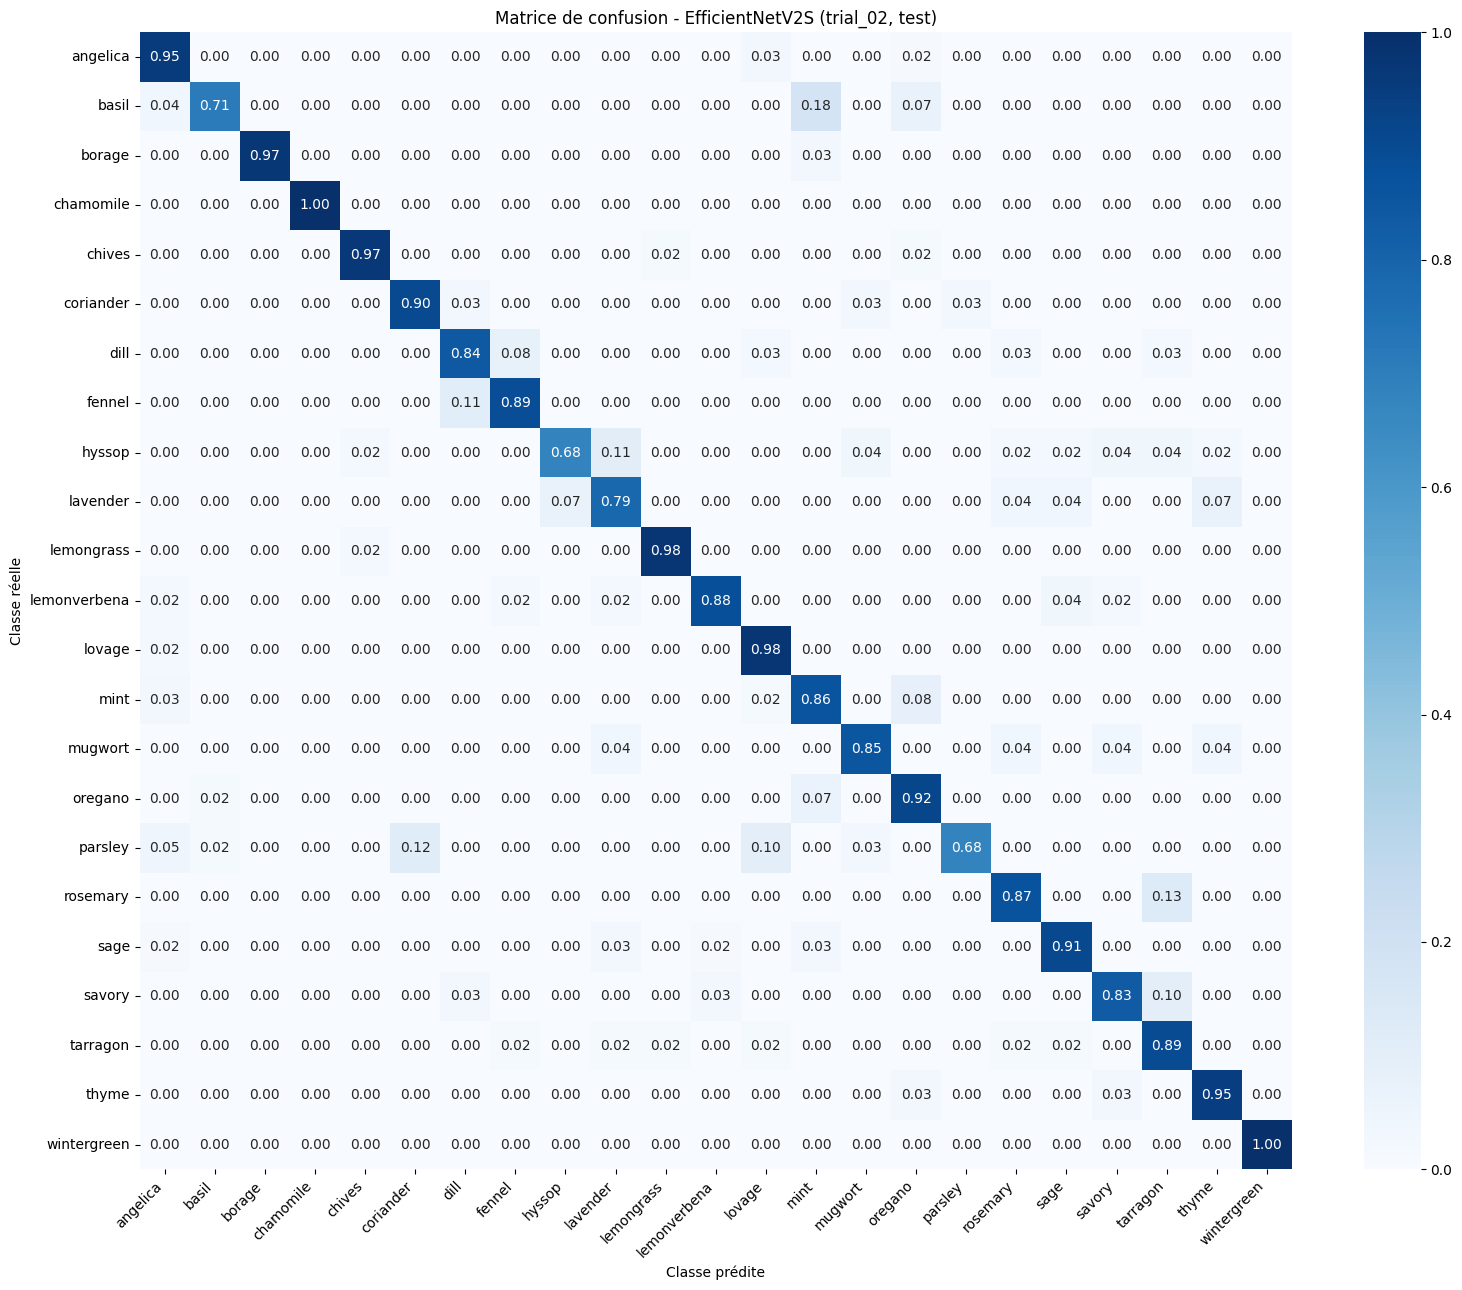

In [43]:
# Matrice de confusion du meilleur modèle après fine-tuning

BEST_FINE_TUNED_MODEL_NAME = fine_tuned_test_eval_df.loc[0, "model_name"]
BEST_FINE_TUNED_TRIAL_NAME = best_fine_tune_runs[BEST_FINE_TUNED_MODEL_NAME]["trial_name"]

best_fine_tuned_eval = fine_tuned_test_eval_artifacts[BEST_FINE_TUNED_MODEL_NAME]

cm = confusion_matrix(
    best_fine_tuned_eval["y_true"],
    best_fine_tuned_eval["y_pred"],
    labels=np.arange(NUM_CLASSES),
    normalize=CONFUSION_NORMALIZE,
)

cm_fmt = ".2f" if CONFUSION_NORMALIZE is not None else "d"

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm,
    annot=True,
    fmt=cm_fmt,
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title(
    f"Matrice de confusion - {BEST_FINE_TUNED_MODEL_NAME} ({BEST_FINE_TUNED_TRIAL_NAME}, test)"
)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [44]:
# Rapport détaillé et classement final

best_fine_tuned_report_df = pd.DataFrame(
    classification_report(
        best_fine_tuned_eval["y_true"],
        best_fine_tuned_eval["y_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T

FINAL_MODEL_RANKING = fine_tuned_test_eval_df["model_name"].tolist()

print("Meilleur modèle final après fine-tuning :", BEST_FINE_TUNED_MODEL_NAME)
print("Classement final des modèles :", FINAL_MODEL_RANKING)
print("Configuration gagnante :")
print(best_fine_tune_trials[BEST_FINE_TUNED_MODEL_NAME]["config"])

display(best_fine_tuned_report_df)


Meilleur modèle final après fine-tuning : EfficientNetV2S
Classement final des modèles : ['EfficientNetV2S', 'EfficientNetB4']
Configuration gagnante :
{'unfreeze_fraction': 0.4, 'learning_rate': 3e-05, 'fine_tune_epochs': 20, 'use_class_weights': True, 'freeze_batchnorm': True}


,precision,recall,f1-score,support
angelica,0.873239,0.953846,0.911765,65.0000
basil,0.909091,0.714286,0.800000,28.0000
borage,1.000000,0.970588,0.985075,34.0000
chamomile,1.000000,1.000000,1.000000,66.0000
chives,0.967742,0.967742,0.967742,62.0000
coriander,0.800000,0.903226,0.848485,31.0000
dill,0.761905,0.842105,0.800000,38.0000
fennel,0.927536,0.888889,0.907801,72.0000
hyssop,0.941176,0.680851,0.790123,47.0000
lavender,0.687500,0.785714,0.733333,28.0000


In [60]:
# Cellule - Dossier d'export du meilleur modèle

from pathlib import Path
from datetime import datetime
import pickle

EXPORT_DIR = PROJECT_DIR / "artifacts" / "tensorflow"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_NAME = fine_tuned_test_eval_df.loc[0, "model_name"]
BEST_MODEL_RUN = best_fine_tune_runs[BEST_MODEL_NAME]
BEST_MODEL = BEST_MODEL_RUN["model"]

timestamp = datetime.now().strftime("%d%m-%H%M")
safe_model_name = BEST_MODEL_NAME.replace(" ", "_").replace("/", "_")

BEST_MODEL_DIR = EXPORT_DIR
print("Export dir:", BEST_MODEL_DIR)


Export dir: /home/thomashebert99/code/thomashebert99/plant_detect/artifacts/tensorflow


In [61]:
# Cellule - Préparer les artefacts

best_test_row = fine_tuned_test_eval_df.iloc[0].to_dict()
best_input_size = TF_MODELS[BEST_MODEL_NAME]["input_size"]

metadata = {
    "model_name": BEST_MODEL_NAME,
    "saved_at": timestamp,
    "data_layout": DATA_LAYOUT,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "input_size": list(best_input_size),
    "batch_size": TF_MODELS[BEST_MODEL_NAME].get("batch_size", BATCH_SIZE),
    "best_trial_name": BEST_MODEL_RUN.get("trial_name"),
    "fine_tune_config": BEST_MODEL_RUN.get("config", {}),
    "test_metrics": {
        k: float(v) if isinstance(v, (np.floating, float)) else v
        for k, v in best_test_row.items()
    },
}

label_artifacts = {
    "class_names": CLASS_NAMES,
    "label_to_index": label_to_index,
    "index_to_label": index_to_label,
}


In [62]:
# Cellule - Sauvegarder le modèle et les artefacts

model_path = BEST_MODEL_DIR / f"{safe_model_name}_model_{timestamp}.keras"
labels_path = BEST_MODEL_DIR / f"{safe_model_name}_labels_{timestamp}.pkl"
metadata_path = BEST_MODEL_DIR / f"{safe_model_name}_metadata_{timestamp}.pkl"

BEST_MODEL.save(model_path)

with open(labels_path, "wb") as f:
    pickle.dump(label_artifacts, f)

with open(metadata_path, "wb") as f:
    pickle.dump(metadata, f)

print("Model saved to    :", model_path)
print("Labels saved to   :", labels_path)
print("Metadata saved to :", metadata_path)


Model saved to    : /home/thomashebert99/code/thomashebert99/plant_detect/artifacts/tensorflow/EfficientNetV2S_model_2203-2212.keras
Labels saved to   : /home/thomashebert99/code/thomashebert99/plant_detect/artifacts/tensorflow/EfficientNetV2S_labels_2203-2212.pkl
Metadata saved to : /home/thomashebert99/code/thomashebert99/plant_detect/artifacts/tensorflow/EfficientNetV2S_metadata_2203-2212.pkl


In [63]:
# Cellule - Vérifier que le rechargement fonctionne

reloaded_model = tf.keras.models.load_model(model_path)

with open(labels_path, "rb") as f:
    reloaded_labels = pickle.load(f)

with open(metadata_path, "rb") as f:
    reloaded_metadata = pickle.load(f)

print("Reloaded model :", reloaded_model.name)
print("Reloaded labels keys   :", reloaded_labels.keys())
print("Reloaded metadata keys :", reloaded_metadata.keys())


Reloaded model : EfficientNetV2S_transfer
Reloaded labels keys   : dict_keys(['class_names', 'label_to_index', 'index_to_label'])
Reloaded metadata keys : dict_keys(['model_name', 'saved_at', 'data_layout', 'num_classes', 'class_names', 'input_size', 'batch_size', 'best_trial_name', 'fine_tune_config', 'test_metrics'])


In [64]:
# Cellule - Rechargement pour inférence

with open(metadata_path, "rb") as f:
    metadata_loaded = pickle.load(f)

with open(labels_path, "rb") as f:
    labels_loaded = pickle.load(f)

model_loaded = tf.keras.models.load_model(model_path)

index_to_label_loaded = labels_loaded["index_to_label"]
print(metadata_loaded["model_name"])
print(index_to_label_loaded)


EfficientNetV2S
{0: 'angelica', 1: 'basil', 2: 'borage', 3: 'chamomile', 4: 'chives', 5: 'coriander', 6: 'dill', 7: 'fennel', 8: 'hyssop', 9: 'lavender', 10: 'lemongrass', 11: 'lemonverbena', 12: 'lovage', 13: 'mint', 14: 'mugwort', 15: 'oregano', 16: 'parsley', 17: 'rosemary', 18: 'sage', 19: 'savory', 20: 'tarragon', 21: 'thyme', 22: 'wintergreen'}


In [75]:
# Cellule - Récupérer les prédictions du meilleur modèle sur train / val / test

best_model_eval_run = {
    "model_name": BEST_MODEL_NAME,
    "model": BEST_MODEL,
}
print(best_model_eval_run)

train_eval = evaluate_multiclass_model(best_model_eval_run, df_train, split_name="train")
val_eval = evaluate_multiclass_model(best_model_eval_run, df_val, split_name="val")
test_eval = evaluate_multiclass_model(best_model_eval_run, df_test, split_name="test")


{'model_name': 'EfficientNetV2S', 'model': <Functional name=EfficientNetV2S_transfer, built=True>}


In [69]:
# Cellule - Tableau global de diagnostic d'overfit

overfit_df = pd.DataFrame([
    {"split": "train", **train_eval["metrics"]},
    {"split": "val", **val_eval["metrics"]},
    {"split": "test", **test_eval["metrics"]},
])

display(overfit_df[[
    "split",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "top_3_accuracy",
    "log_loss",
    "ranking_score",
]])


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,top_3_accuracy,log_loss,ranking_score
0,train,0.994921,0.995909,0.994730,0.994927,1.000000,0.017767,0.995894
1,val,0.917046,0.910655,0.908973,0.916678,0.985415,0.310481,0.921751
2,test,0.889800,0.883134,0.880451,0.889175,0.982696,0.387770,0.897527


In [70]:
# Cellule - Gaps plus complets

train_row = overfit_df[overfit_df["split"] == "train"].iloc[0]
val_row = overfit_df[overfit_df["split"] == "val"].iloc[0]
test_row = overfit_df[overfit_df["split"] == "test"].iloc[0]

overfit_gaps_df = pd.DataFrame([
    {
        "metric": "accuracy",
        "train_minus_val": train_row["accuracy"] - val_row["accuracy"],
        "train_minus_test": train_row["accuracy"] - test_row["accuracy"],
        "val_minus_test": val_row["accuracy"] - test_row["accuracy"],
    },
    {
        "metric": "balanced_accuracy",
        "train_minus_val": train_row["balanced_accuracy"] - val_row["balanced_accuracy"],
        "train_minus_test": train_row["balanced_accuracy"] - test_row["balanced_accuracy"],
        "val_minus_test": val_row["balanced_accuracy"] - test_row["balanced_accuracy"],
    },
    {
        "metric": "macro_f1",
        "train_minus_val": train_row["macro_f1"] - val_row["macro_f1"],
        "train_minus_test": train_row["macro_f1"] - test_row["macro_f1"],
        "val_minus_test": val_row["macro_f1"] - test_row["macro_f1"],
    },
    {
        "metric": "log_loss",
        "train_minus_val": train_row["log_loss"] - val_row["log_loss"],
        "train_minus_test": train_row["log_loss"] - test_row["log_loss"],
        "val_minus_test": val_row["log_loss"] - test_row["log_loss"],
    },
])

display(overfit_gaps_df)


,metric,train_minus_val,train_minus_test,val_minus_test
0,accuracy,0.077874,0.105121,0.027247
1,balanced_accuracy,0.085255,0.112775,0.027521
2,macro_f1,0.085757,0.114279,0.028522
3,log_loss,-0.292714,-0.370002,-0.077289


In [71]:
# Cellule - Rapport par classe pour voir si l'overfit touche surtout certaines espèces

from sklearn.metrics import classification_report

train_report_df = pd.DataFrame(
    classification_report(
        train_eval["y_true"],
        train_eval["y_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T

val_report_df = pd.DataFrame(
    classification_report(
        val_eval["y_true"],
        val_eval["y_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T

test_report_df = pd.DataFrame(
    classification_report(
        test_eval["y_true"],
        test_eval["y_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T

per_class_gap_df = pd.DataFrame({
    "train_f1": train_report_df["f1-score"],
    "val_f1": val_report_df["f1-score"],
    "test_f1": test_report_df["f1-score"],
    "support_train": train_report_df["support"],
    "support_val": val_report_df["support"],
    "support_test": test_report_df["support"],
}).iloc[:NUM_CLASSES]

per_class_gap_df["train_minus_val_f1"] = per_class_gap_df["train_f1"] - per_class_gap_df["val_f1"]
per_class_gap_df["train_minus_test_f1"] = per_class_gap_df["train_f1"] - per_class_gap_df["test_f1"]

display(per_class_gap_df.sort_values("train_minus_val_f1", ascending=False))


,train_f1,val_f1,test_f1,support_train,support_val,support_test,train_minus_val_f1,train_minus_test_f1
dill,0.997167,0.805195,0.800000,176.0,38.0,38.0,0.191972,0.197167
coriander,0.957377,0.766667,0.848485,146.0,31.0,31.0,0.190710,0.108892
mugwort,1.000000,0.836364,0.836364,125.0,27.0,27.0,0.163636,0.163636
basil,0.996169,0.846154,0.800000,131.0,28.0,28.0,0.150015,0.196169
parsley,0.968921,0.833333,0.803922,282.0,60.0,60.0,0.135588,0.165000
rosemary,0.993056,0.865672,0.857143,143.0,31.0,31.0,0.127384,0.135913
mint,0.996364,0.870968,0.836066,275.0,59.0,59.0,0.125396,0.160298
savory,1.000000,0.881356,0.819672,142.0,31.0,30.0,0.118644,0.180328
lovage,0.989529,0.883721,0.869565,189.0,40.0,41.0,0.105808,0.119964
thyme,0.994065,0.900000,0.945205,339.0,73.0,73.0,0.094065,0.048860


In [72]:
# Cellule - Diagnostic de surconfiance du modèle

def confidence_stats(eval_dict, split_name):
    y_true = np.array(eval_dict["y_true"])
    y_pred = np.array(eval_dict["y_pred"])
    y_proba = np.array(eval_dict["y_proba"])

    max_proba = y_proba.max(axis=1)
    correct_mask = y_true == y_pred

    return {
        "split": split_name,
        "mean_confidence": float(max_proba.mean()),
        "mean_confidence_correct": float(max_proba[correct_mask].mean()) if correct_mask.any() else np.nan,
        "mean_confidence_incorrect": float(max_proba[~correct_mask].mean()) if (~correct_mask).any() else np.nan,
        "std_confidence": float(max_proba.std()),
    }

confidence_df = pd.DataFrame([
    confidence_stats(train_eval, "train"),
    confidence_stats(val_eval, "val"),
    confidence_stats(test_eval, "test"),
])

display(confidence_df)


,split,mean_confidence,mean_confidence_correct,mean_confidence_incorrect,std_confidence
0,train,0.989635,0.991075,0.707570,0.044572
1,val,0.948363,0.964828,0.766340,0.117974
2,test,0.941240,0.964688,0.751918,0.127436


In [73]:
# Cellule - ECE simple (Expected Calibration Error)

def expected_calibration_error(y_true, y_proba, n_bins=10):
    y_true = np.array(y_true)
    y_proba = np.array(y_proba)

    pred = y_proba.argmax(axis=1)
    conf = y_proba.max(axis=1)
    correct = (pred == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        mask = (conf > left) & (conf <= right) if i > 0 else (conf >= left) & (conf <= right)

        if mask.sum() == 0:
            continue

        bin_acc = correct[mask].mean()
        bin_conf = conf[mask].mean()
        ece += (mask.sum() / len(conf)) * abs(bin_acc - bin_conf)

    return float(ece)

ece_df = pd.DataFrame([
    {
        "split": "train",
        "ece": expected_calibration_error(train_eval["y_true"], train_eval["y_proba"]),
    },
    {
        "split": "val",
        "ece": expected_calibration_error(val_eval["y_true"], val_eval["y_proba"]),
    },
    {
        "split": "test",
        "ece": expected_calibration_error(test_eval["y_true"], test_eval["y_proba"]),
    },
])

display(ece_df)


,split,ece
0,train,0.005371
1,val,0.037312
2,test,0.051441


In [74]:
# Cellule - Verdict synthétique

macro_f1_gap = train_row["macro_f1"] - val_row["macro_f1"]
balanced_gap = train_row["balanced_accuracy"] - val_row["balanced_accuracy"]
logloss_gap = val_row["log_loss"] - train_row["log_loss"]

print(f"Gap train-val macro_f1           : {macro_f1_gap:.4f}")
print(f"Gap train-val balanced_accuracy  : {balanced_gap:.4f}")
print(f"Gap val-train log_loss           : {logloss_gap:.4f}")

if macro_f1_gap > 0.08 or balanced_gap > 0.08:
    print("Signal d'overfitting assez net.")
elif macro_f1_gap > 0.04 or balanced_gap > 0.04:
    print("Overfitting modéré à surveiller.")
else:
    print("Pas de signal fort d'overfitting.")

if ece_df.loc[ece_df["split"] == "train", "ece"].iloc[0] < ece_df.loc[ece_df["split"] == "val", "ece"].iloc[0]:
    print("Le modèle semble plus mal calibré hors train, ce qui renforce l'hypothèse d'overfit.")


Gap train-val macro_f1           : 0.0858
Gap train-val balanced_accuracy  : 0.0853
Gap val-train log_loss           : 0.2927
Signal d'overfitting assez net.
Le modèle semble plus mal calibré hors train, ce qui renforce l'hypothèse d'overfit.
